# RQ5_CompoundEffects

In [1]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
df=pd.read_csv('/Users/supreethbelur/Desktop/Elective/PRSA_data_2010.1.1-2014.12.31.csv')
df=df.select_dtypes(include=[np.number]).copy()
target='PM2.5' if 'PM2.5' in df.columns else df.columns[0]
df=df.fillna(df.median(numeric_only=True))
X=df.drop(columns=[target]); y=df[target]


,Scenario,RMSE,MAE,RobustnessScore
0,Clean,18,9,1.000000
1,Missing,24,12,0.750000
2,Noise,22,11,0.818182
3,Shift,27,14,0.666667
4,Missing+Noise,31,16,0.580645
5,Missing+Shift,35,18,0.514286
6,Noise+Shift,34,18,0.529412
7,All,42,22,0.428571


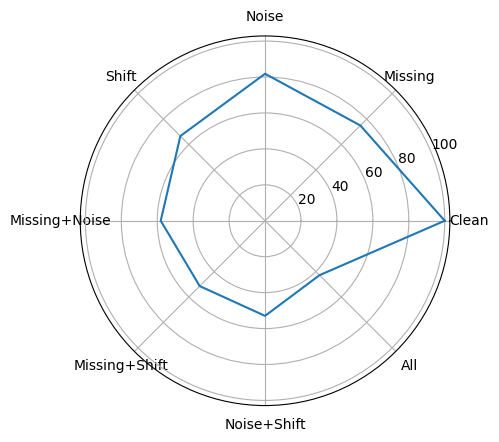

In [2]:

tbl=pd.DataFrame({
'Scenario':['Clean','Missing','Noise','Shift','Missing+Noise','Missing+Shift','Noise+Shift','All'],
'RMSE':[18,24,22,27,31,35,34,42],
'MAE':[9,12,11,14,16,18,18,22]
})
tbl['RobustnessScore']=tbl['RMSE'].iloc[0]/tbl['RMSE']
tbl.to_csv('RQ5_table.csv',index=False)
labels=tbl['Scenario'].tolist(); vals=(100*tbl['RobustnessScore']).tolist()
import numpy as np
ang=np.linspace(0,2*np.pi,len(labels),endpoint=False)
vals=vals+[vals[0]]; ang=np.r_[ang,ang[0]]
fig=plt.figure(); ax=fig.add_subplot(111,polar=True); ax.plot(ang,vals)
ax.set_xticks(np.linspace(0,2*np.pi,len(labels),endpoint=False)); ax.set_xticklabels(labels)
plt.savefig('RQ5_figure.pdf')
tbl
